# CT Brain Image Classification using ResNet50
This notebook trains a ResNet50 model on a CT Brain dataset.
The dataset is divided into 3 scenarios for train/val/test splits.

### Skenario:
1. 80% train, 10% val, 10% test
2. 70% train, 20% val, 10% test
3. 60% train, 30% val, 10% test

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm

In [ ]:
# ==========================================
# GLOBAL PARAMETER FOR SPLITTING SCENARIO
# ==========================================
# 1: 80% train, 10% val, 10% test
# 2: 70% train, 20% val, 10% test
# 3: 60% train, 30% val, 10% test
SCENARIO = 2

# Other Hyperparameters
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 1e-2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [3]:
# Load CSV and prepare paths
csv_path = '..dataset/ct_brain.csv'
base_img_path = '..dataset/files'

df = pd.read_csv(csv_path)
# Create the full path for the images by appending the base directory to the relative path from the csv
df['full_path'] = base_img_path + df['jpg']

# Encode labels
label_mapping = {label: idx for idx, label in enumerate(df['type'].unique())}
df['label'] = df['type'].map(label_mapping)
print('Label Mapping:', label_mapping)
print(f'Total data points: {len(df)}')
display(df.head())

Label Mapping: {'aneurysm': 0, 'tumor': 1, 'cancer': 2}
Total data points: 256


,dcm,jpg,type,full_path,label
0,/aneurysm/0.dcm,/aneurysm/0.jpg,aneurysm,..dataset/files/aneurysm/0.jpg,0
1,/aneurysm/1.dcm,/aneurysm/1.jpg,aneurysm,..dataset/files/aneurysm/1.jpg,0
2,/aneurysm/2.dcm,/aneurysm/2.jpg,aneurysm,..dataset/files/aneurysm/2.jpg,0
3,/aneurysm/3.dcm,/aneurysm/3.jpg,aneurysm,..dataset/files/aneurysm/3.jpg,0
4,/aneurysm/4.dcm,/aneurysm/4.jpg,aneurysm,..dataset/files/aneurysm/4.jpg,0


In [ ]:
def split_dataset(df, scenario):
    if scenario == 1:
        train_ratio, val_ratio, test_ratio = 0.8, 0.1, 0.1
    elif scenario == 2:
        train_ratio, val_ratio, test_ratio = 0.7, 0.2, 0.1

        train_ratio, val_ratio, test_ratio = 0.6, 0.3, 0.1
    else:
        raise ValueError('Invalid scenario. Choose 1, 2, or 3.')

    # First, split out the train set from the rest (val + test)
    rest_ratio = val_ratio + test_ratio
    train_df, temp_df = train_test_split(df, test_size=rest_ratio, random_state=42, stratify=df['label'])

    # Now split the temporary set into val and test proportionally
    val_df, test_df = train_test_split(temp_df, test_size=(test_ratio / rest_ratio), random_state=42, stratify=temp_df['label'])

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, val_df, test_df = split_dataset(df, SCENARIO)
print(f'Scenario {SCENARIO} Split:')
print(f'Train size: {len(train_df)}')
print(f'Val size: {len(val_df)}')
print(f'Test size: {len(test_df)}')

Scenario 3 Split:
Train size: 153
Val size: 77
Test size: 26


In [ ]:
# Dataset Class
class CTBrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'full_path']
        label = self.df.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

# Image Transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create DataLoaders
train_dataset = CTBrainDataset(train_df, transform=train_transform)
val_dataset = CTBrainDataset(val_df, transform=test_transform)
test_dataset = CTBrainDataset(test_df, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
# Model Initialization (ResNet50)
num_classes = len(label_mapping)

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Modify the final fully connected layer for our number of classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(DEVICE)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
# Training and Validation Loop
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for images, labels in train_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}')

Epoch 1/30 [Train]: 100%|██████████| 10/10 [00:03<00:00,  2.90it/s]


Train Loss: 0.9159, Train Acc: 0.7320 | Val Loss: 0.9613, Val Acc: 0.7273


Epoch 2/30 [Train]: 100%|██████████| 10/10 [00:03<00:00,  3.13it/s]


Train Loss: 0.4446, Train Acc: 0.9869 | Val Loss: 0.6219, Val Acc: 0.8961


Epoch 3/30 [Train]: 100%|██████████| 10/10 [00:03<00:00,  3.07it/s]


...

Train Loss: 0.0008, Train Acc: 1.0000 | Val Loss: 0.1936, Val Acc: 0.9610


Epoch 29/30 [Train]: 100%|██████████| 10/10 [00:03<00:00,  2.93it/s]


Train Loss: 0.0009, Train Acc: 1.0000 | Val Loss: 0.1896, Val Acc: 0.9610


Epoch 30/30 [Train]: 100%|██████████| 10/10 [00:03<00:00,  2.93it/s]


Train Loss: 0.0009, Train Acc: 1.0000 | Val Loss: 0.2046, Val Acc: 0.9610


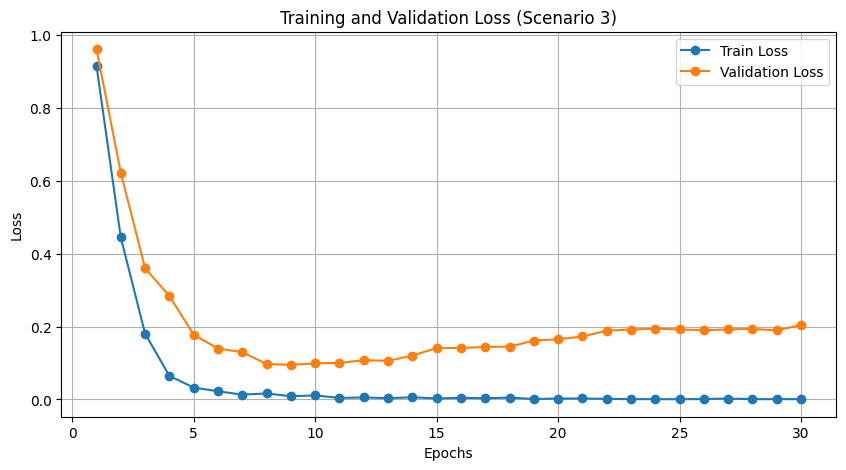

In [12]:
# Plotting Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'Training and Validation Loss (Scenario {SCENARIO})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plotting Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_accuracies, label='Train Accuracy', marker='o')
plt.plot(range(1, EPOCHS+1), val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Training and Validation Accuracy (Scenario {SCENARIO})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluation on Test Set
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Calculate Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('='*40)
print(f'Test Evaluation Metrics (Scenario {SCENARIO}):')
print('='*40)
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-Score : {f1:.4f}\n')

print('Classification Report:')
target_names = [k for k, v in sorted(label_mapping.items(), key=lambda item: item[1])]
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

Testing: 100%|██████████| 2/2 [00:00<00:00,  8.13it/s]

Test Evaluation Metrics (Scenario 3):
Accuracy : 0.9231
Precision: 0.9274
Recall   : 0.9231
F1-Score : 0.9231

Classification Report:
              precision    recall  f1-score   support

    aneurysm       0.89      0.89      0.89         9
       tumor       0.89      1.00      0.94         8
      cancer       1.00      0.89      0.94         9

    accuracy                           0.92        26
   macro avg       0.93      0.93      0.92        26
weighted avg       0.93      0.92      0.92        26

